# Step 4: TFIDF & Vector Space (F4)

Abraham Tedla (wqp7qy@virginia.edu)  
DS 5001  
April 2026

Build a bag-of-words document-term matrix, compute TF, IDF, and TFIDF. Add results to TOKEN and VOCAB.

# Set Up

In [26]:
import pandas as pd
import numpy as np
import os

np.random.seed(42)

In [27]:
import seaborn as sns
sns.set()
%matplotlib inline

In [28]:
output_dir = 'output'

OHCO = ['book_id', 'chapter', 'para_num', 'sent_num']
BOOKS = OHCO[:1]
CHAPS = OHCO[:2]

# Load F3 Data

In [29]:
TOKEN = pd.read_csv(os.path.join(output_dir, 'TOKEN.csv')).set_index(OHCO + ['token_num']).sort_index()
VOCAB = pd.read_csv(os.path.join(output_dir, 'VOCAB.csv')).set_index('term_str')
LIBRARY = pd.read_csv(os.path.join(output_dir, 'LIBRARY.csv')).set_index('book_id').sort_index()

In [30]:
TOKEN.head()

token_str      term_str  pos  \
book_id chapter para_num sent_num token_num                                    
35      1       0        0        0          Introduction  introduction   NN   
                1        0        0                   The           the   DT   
                                  1                  Time          time  NNP   
                                  2             Traveller     traveller  NNP   
                                  3                   for           for   IN   

                                             term_id  stop       stem  \
book_id chapter para_num sent_num token_num                             
35      1       0        0        0             4713     0  introduct   
                1        0        0                0     1        the   
                                  1               71     0       time   
                                  2             1169     0     travel   
                                  3               19     1        for   

                                                    lemma  negative  positive  \
book_id chapter para_num sent_num token_num                                     
35      1       0        0        0          introduction         0         0   
                1        0        0                   the         0         0   
                                  1                  time         0         0   
                                  2             traveller         0         0   
                                  3                   for         0         0   

                                             anger  anticipation  disgust  \
book_id chapter para_num sent_num token_num                                 
35      1       0        0        0              0             0        0   
                1        0        0              0             0        0   
                                  1              0             1        0   
                                  2              0             0        0   
                                  3              0             0        0   

                                             fear  joy  sadness  surprise  \
book_id chapter para_num sent_num token_num                                 
35      1       0        0        0             0    0        0         0   
                1        0        0             0    0        0         0   
                                  1             0    0        0         0   
                                  2             0    0        0         0   
                                  3             0    0        0         0   

                                             trust  polarity  
book_id chapter para_num sent_num token_num                   
35      1       0        0        0              0         0  
                1        0        0              0         0  
                                  1              0         0  
                                  2              0         0  
                                  3              0         0

In [31]:
VOCAB.head()

,n,df,max_pos,term_id,stop,stem,lemma,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,polarity
term_str,,,,,,,,,,,,,,,,,,
the,51573,12,DT,0,1,the,the,0,0,0,0,0,0,0,0,0,0,0
and,29951,12,CC,1,1,and,and,0,0,0,0,0,0,0,0,0,0,0
of,26564,12,IN,2,1,of,of,0,0,0,0,0,0,0,0,0,0,0
i,24740,12,PRP,3,1,i,i,0,0,0,0,0,0,0,0,0,0,0
to,22596,12,TO,4,1,to,to,0,0,0,0,0,0,0,0,0,0,0


In [32]:
n_docs = LIBRARY.shape[0]
print(f'Number of documents (books): {n_docs}')

Number of documents (books): 12


# Build Bag-of-Words (Document-Term Matrix)

Count term occurrences per book. This is our raw count matrix.

In [33]:
BOW = TOKEN.groupby(BOOKS + ['term_str']).size().rename('n').reset_index()
BOW.head()

,book_id,term_str,n
0,35,a,817
1,35,abandon,1
2,35,abandoned,1
3,35,able,3
4,35,abnormally,1


In [34]:
# Pivot to document-term matrix
DTCM = BOW.pivot_table(index='book_id', columns='term_str', values='n', fill_value=0)
print(f'DTCM shape: {DTCM.shape}')
DTCM.iloc[:5, :10]

DTCM shape: (12, 25122)


term_str,a,aback,abaft,abaht,abandon,abandoned,abandoning,abandonment,abart,abasement
book_id,,,,,,,,,,
35,817.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
36,1632.0,0.0,0.0,0.0,0.0,7.0,1.0,0.0,1.0,0.0
42,634.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
62,1260.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
84,1391.0,0.0,0.0,0.0,2.0,3.0,0.0,0.0,0.0,0.0


# Compute TF (Term Frequency)

Normalize counts by total tokens per document.

In [35]:
doc_totals = DTCM.sum(axis=1)
TF = DTCM.div(doc_totals, axis=0)
TF.iloc[:5, :10]

term_str,a,aback,abaft,abaht,abandon,abandoned,abandoning,abandonment,abart,abasement
book_id,,,,,,,,,,
35,0.025170,0.0,0.0,0.0,0.000031,0.000031,0.000000,0.0,0.000000,0.0
36,0.027171,0.0,0.0,0.0,0.000000,0.000117,0.000017,0.0,0.000017,0.0
42,0.024897,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0
62,0.019125,0.0,0.0,0.0,0.000000,0.000000,0.000015,0.0,0.000000,0.0
84,0.018572,0.0,0.0,0.0,0.000027,0.000040,0.000000,0.0,0.000000,0.0


# Compute IDF (Inverse Document Frequency)

$IDF(t) = \log\left(\frac{N}{df(t)}\right)$

where $N$ is the number of documents and $df(t)$ is the number of documents containing term $t$.

In [36]:
DF = (DTCM > 0).sum(axis=0).rename('df')
IDF = np.log(n_docs / DF).rename('idf')
IDF.describe()

count    25122.000000
mean         1.724427
std          0.823950
min          0.000000
25%          1.098612
50%          1.791759
75%          2.484907
max          2.484907
Name: idf, dtype: float64

In [37]:
# Terms with highest IDF (appear in fewest docs)
IDF.sort_values(ascending=False).head(20)

term_str
œdipus          2.484907
protectors      2.484907
protract        2.484907
fleets          2.484907
protexta        2.484907
proteus         2.484907
protestants     2.484907
fletcher        2.484907
flexibility     2.484907
protects        2.484907
flick           2.484907
flicking        2.484907
protraction     2.484907
flier           2.484907
fliers          2.484907
protections     2.484907
protectingly    2.484907
flighted        2.484907
prostrating     2.484907
prostrated      2.484907
Name: idf, dtype: float64

In [38]:
# Terms with lowest IDF (appear in all docs)
IDF.sort_values().head(20)

term_str
a             0.0
extent        0.0
death         0.0
run           0.0
hard          0.0
expression    0.0
round         0.0
rose          0.0
happen        0.0
meet          0.0
running       0.0
meeting       0.0
deep          0.0
deeply        0.0
room          0.0
hands         0.0
roof          0.0
trouble       0.0
hand          0.0
while         0.0
Name: idf, dtype: float64

# Compute TFIDF

$TFIDF(t, d) = TF(t, d) \times IDF(t)$

In [39]:
TFIDF = TF.mul(IDF, axis=1)
print(f'TFIDF shape: {TFIDF.shape}')
TFIDF.iloc[:5, :10]

TFIDF shape: (12, 25122)


term_str,a,aback,abaft,abaht,abandon,abandoned,abandoning,abandonment,abart,abasement
book_id,,,,,,,,,,
35,0.0,0.0,0.0,0.0,0.000012,0.000009,0.000000,0.0,0.000000,0.0
36,0.0,0.0,0.0,0.0,0.000000,0.000034,0.000018,0.0,0.000041,0.0
42,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0
62,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000017,0.0,0.000000,0.0
84,0.0,0.0,0.0,0.0,0.000011,0.000012,0.000000,0.0,0.000000,0.0


## Top TFIDF Terms per Book

In [40]:
for book_id in LIBRARY.index:
    title = LIBRARY.loc[book_id, 'title']
    top = TFIDF.loc[book_id].sort_values(ascending=False).head(10)
    print(f'\n--- {title} (book_id={book_id}) ---')
    print(top.to_string())


--- The Time Machine (book_id=35) ---
term_str
weena           0.004134
morlocks        0.003598
machine         0.001836
traveller       0.001699
psychologist    0.001380
filby           0.001301
sphinx          0.001270
editor          0.000854
camphor         0.000842
underworld      0.000766

--- The War of the Worlds (book_id=36) ---
term_str
martians        0.004862
martian         0.002446
woking          0.002151
cylinder        0.001207
artilleryman    0.001200
weybridge       0.001117
ulla            0.001117
horsell         0.000993
mars            0.000969
ogilvy          0.000910

--- Dr. Jekyll and Mr. Hyde (book_id=42) ---
term_str
utterson    0.012783
jekyll      0.009465
hyde        0.005389
poole       0.004292
lawyer      0.003920
lanyon      0.003123
enfield     0.001854
henry       0.001251
cabinet     0.001122
edward      0.000859

--- A Princess of Mars (book_id=62) ---
term_str
dejah       0.006638
thoris      0.006601
sola        0.004602
helium      0.004036


# Add TFIDF Stats to VOCAB

Add `idf`, `tfidf_max`, and `tfidf_mean` to the VOCAB table.

In [41]:
VOCAB['idf'] = IDF
VOCAB['tfidf_max'] = TFIDF.max(axis=0)
VOCAB['tfidf_mean'] = TFIDF.mean(axis=0)
VOCAB[['n', 'df', 'idf', 'tfidf_max', 'tfidf_mean']].head(20)

,n,df,idf,tfidf_max,tfidf_mean
term_str,,,,,
the,51573,12,0.0,0.0,0.0
and,29951,12,0.0,0.0,0.0
of,26564,12,0.0,0.0,0.0
i,24740,12,0.0,0.0,0.0
to,22596,12,0.0,0.0,0.0
a,18147,12,0.0,0.0,0.0
in,13074,12,0.0,0.0,0.0
that,11537,12,0.0,0.0,0.0
was,11170,12,0.0,0.0,0.0


# Add TFIDF to TOKEN

Each token gets the TFIDF value for its term in its document.

In [42]:
# Stack TFIDF matrix into long format
tfidf_long = TFIDF.stack().rename('tfidf').reset_index()
tfidf_long.columns = ['book_id', 'term_str', 'tfidf']
tfidf_long = tfidf_long.set_index(['book_id', 'term_str'])
tfidf_long = tfidf_long[tfidf_long['tfidf'] > 0]  # only keep nonzero
print(f'Nonzero TFIDF entries: {len(tfidf_long):,}')

Nonzero TFIDF entries: 69,131


In [43]:
# Join to TOKEN
TOKEN_reset = TOKEN.reset_index()
TOKEN_reset = TOKEN_reset.merge(
    tfidf_long.reset_index(), 
    on=['book_id', 'term_str'], 
    how='left'
)
TOKEN_reset['tfidf'] = TOKEN_reset['tfidf'].fillna(0)
TOKEN = TOKEN_reset.set_index(OHCO + ['token_num']).sort_index()

In [44]:
TOKEN.head(10)

token_str      term_str  pos  \
book_id chapter para_num sent_num token_num                                    
35      1       0        0        0          Introduction  introduction   NN   
                1        0        0                   The           the   DT   
                                  1                  Time          time  NNP   
                                  2             Traveller     traveller  NNP   
                                  3                   for           for   IN   
                                  4                    so            so   IN   
                                  5                    it            it  PRP   
                                  6                  will          will   MD   
                                  7                    be            be   VB   
                                  8            convenient    convenient   JJ   

                                             term_id  stop       stem  \
book_id chapter para_num sent_num token_num                             
35      1       0        0        0             4713     0  introduct   
                1        0        0                0     1        the   
                                  1               71     0       time   
                                  2             1169     0     travel   
                                  3               19     1        for   
                                  4               36     1         so   
                                  5                9     1         it   
                                  6               57     1       will   
                                  7               27     1         be   
                                  8             3523     0    conveni   

                                                    lemma  negative  positive  \
book_id chapter para_num sent_num token_num                                     
35      1       0        0        0          introduction         0         0   
                1        0        0                   the         0         0   
                                  1                  time         0         0   
                                  2             traveller         0         0   
                                  3                   for         0         0   
                                  4                    so         0         0   
                                  5                    it         0         0   
                                  6                  will         0         0   
                                  7                    be         0         0   
                                  8            convenient         0         1   

                                             anger  anticipation  disgust  \
book_id chapter para_num sent_num token_num                                 
35      1       0        0        0              0             0        0   
                1        0        0              0             0        0   
                                  1              0             1        0   
                                  2              0             0        0   
                                  3              0             0        0   
                                  4              0             0        0   
                                  5              0             0        0   
                                  6              0             0        0   
                                  7              0             0        0   
                                  8              0             0        0   

                                             fear  joy  sadness  surprise  \
book_id chapter para_num sent_num token_num                                 
35      1       0        0        0             0    0        0         0   
                1        0        0             0    0        0         0   
    

# Quick Visualizations

<Axes: >

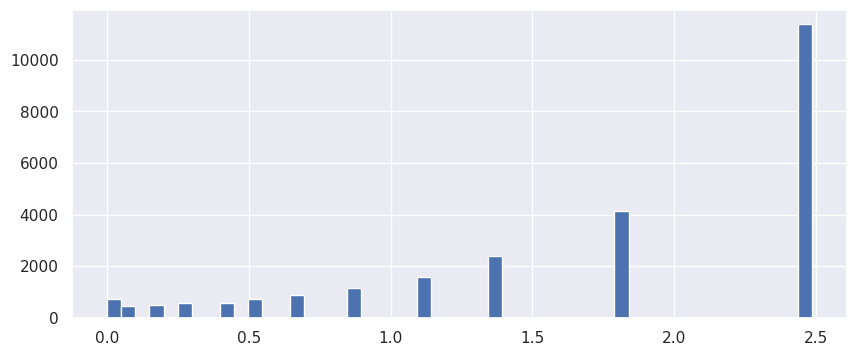

In [45]:
# Distribution of IDF values
VOCAB['idf'].hist(bins=50, figsize=(10, 4))

<Axes: ylabel='term_str'>

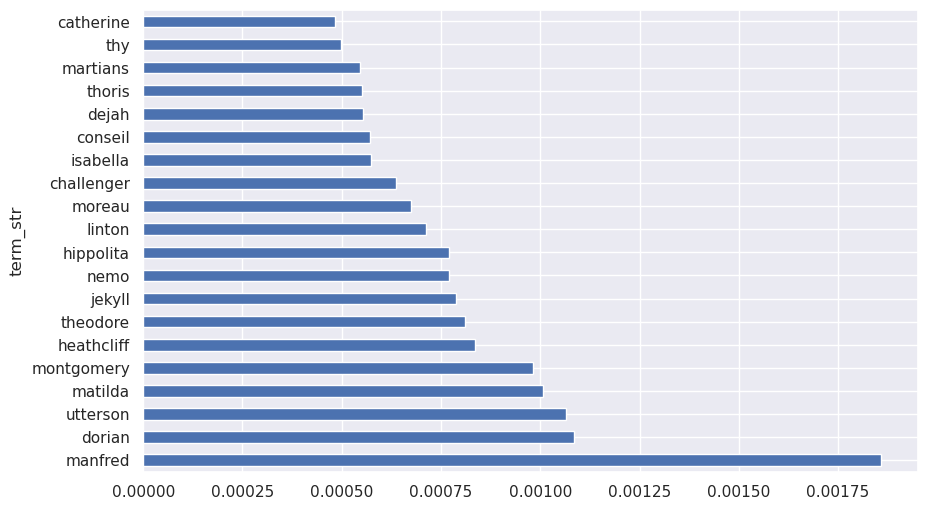

In [46]:
# Top 20 terms by mean TFIDF (most "distinctive" across corpus)
VOCAB.sort_values('tfidf_mean', ascending=False).head(20)['tfidf_mean'].plot.barh(figsize=(10, 6))

# Save Outputs

In [47]:
TOKEN.to_csv(os.path.join(output_dir, 'TOKEN.csv'))
print(f'Saved TOKEN.csv ({len(TOKEN):,} rows)')

Saved TOKEN.csv (871,168 rows)


In [48]:
VOCAB.to_csv(os.path.join(output_dir, 'VOCAB.csv'))
print(f'Saved VOCAB.csv ({len(VOCAB):,} rows)')

Saved VOCAB.csv (25,122 rows)


In [49]:
TFIDF.to_csv(os.path.join(output_dir, 'TFIDF.csv'))
print(f'Saved TFIDF.csv (document-term matrix)')

Saved TFIDF.csv (document-term matrix)


# Summary

- Built document-term count matrix (BOW) from TOKEN.
- Computed TF (normalized by doc length), IDF, and TFIDF.
- Added `idf`, `tfidf_max`, `tfidf_mean` to VOCAB.
- Added per-token `tfidf` to TOKEN.
- Saved updated `TOKEN.csv`, `VOCAB.csv`, and `TFIDF.csv`.

**Next:** Step 5 — Unsupervised Models (F5): PCA, LDA, word2vec.